In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [55]:
df = pd.read_excel("D:/TECHTRECK/01_House_Prices.xlsx")

df.head()

,house_id,area_sqft,bedrooms,bathrooms,house_age_years,distance_city_km,has_garage,neighborhood_score,price_usd
0,H0001,1982.8,2,2.0,3,8.19,Yes,6.09,538319.98
1,H0002,2266.7,4,3.0,31,10.32,Yes,5.95,597950.89
2,H0003,1770.0,3,2.0,3,6.65,Yes,7.89,536099.35
3,H0004,2047.6,3,3.0,43,5.46,Yes,8.00,568164.49
4,H0005,1731.6,2,NaN,25,12.31,No,NaN,388126.72


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   house_id            263 non-null    object 
 1   area_sqft           258 non-null    float64
 2   bedrooms            263 non-null    int64  
 3   bathrooms           258 non-null    float64
 4   house_age_years     263 non-null    int64  
 5   distance_city_km    258 non-null    float64
 6   has_garage          260 non-null    object 
 7   neighborhood_score  258 non-null    float64
 8   price_usd           263 non-null    float64
dtypes: float64(5), int64(2), object(2)
memory usage: 18.6+ KB


In [57]:
df.isna().sum()

house_id              0
area_sqft             5
bedrooms              0
bathrooms             5
house_age_years       0
distance_city_km      5
has_garage            3
neighborhood_score    5
price_usd             0
dtype: int64

In [58]:
df.duplicated().sum()

np.int64(3)

In [59]:
import plotly.express as px 

<Axes: title={'center': 'Number of Null Values in Each Column'}>

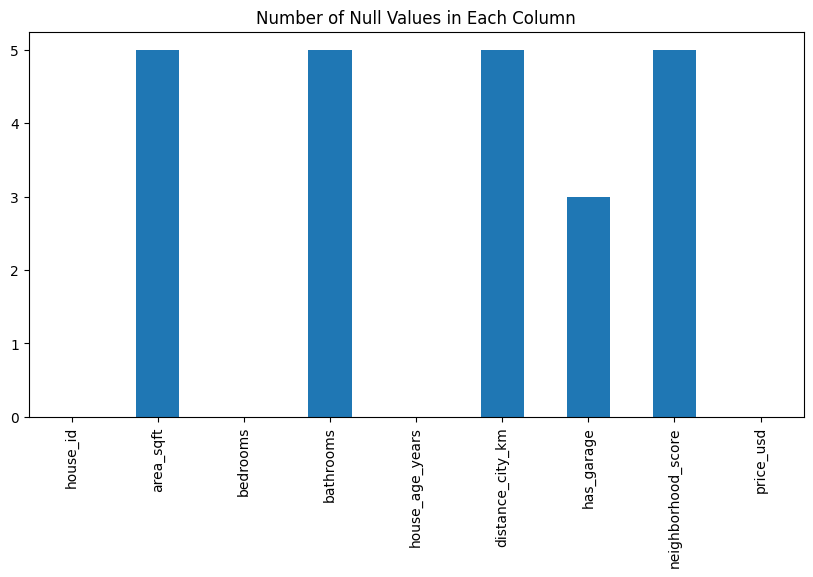

In [60]:
nulls = df.isna().sum()
nulls.plot(kind='bar', figsize=(10, 5), title='Number of Null Values in Each Column')

In [61]:
df.duplicated().sum()

np.int64(3)

In [62]:
df.head()

,house_id,area_sqft,bedrooms,bathrooms,house_age_years,distance_city_km,has_garage,neighborhood_score,price_usd
0,H0001,1982.8,2,2.0,3,8.19,Yes,6.09,538319.98
1,H0002,2266.7,4,3.0,31,10.32,Yes,5.95,597950.89
2,H0003,1770.0,3,2.0,3,6.65,Yes,7.89,536099.35
3,H0004,2047.6,3,3.0,43,5.46,Yes,8.00,568164.49
4,H0005,1731.6,2,NaN,25,12.31,No,NaN,388126.72


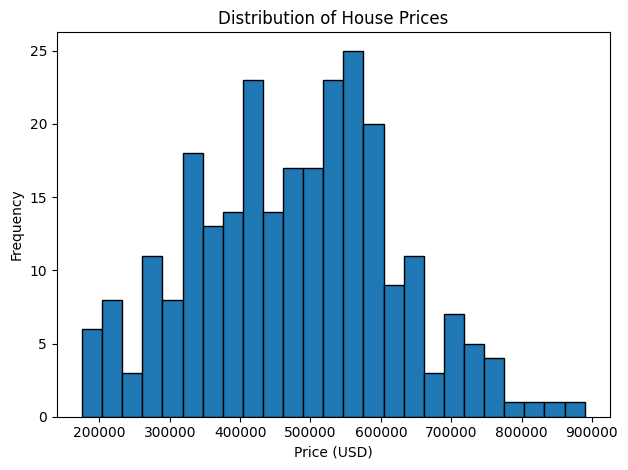

In [63]:
plt.hist(df['price_usd'].dropna(), bins=25, edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

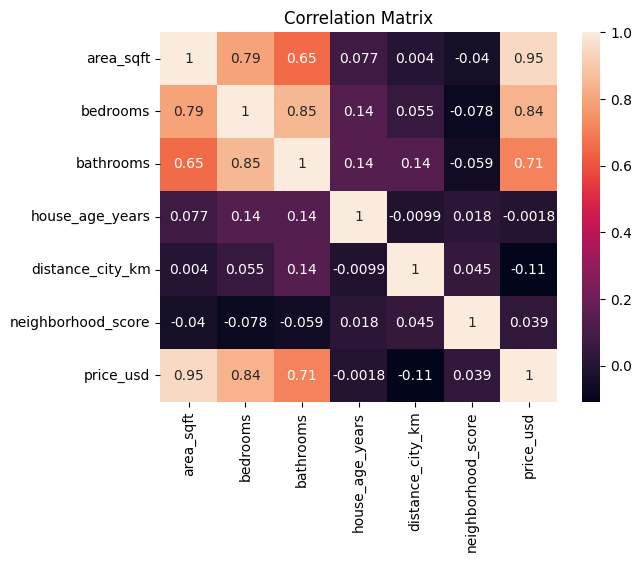

In [64]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

In [65]:
df.isnull().sum()

house_id              0
area_sqft             5
bedrooms              0
bathrooms             5
house_age_years       0
distance_city_km      5
has_garage            3
neighborhood_score    5
price_usd             0
dtype: int64

In [68]:
df.head()

,house_id,area_sqft,bedrooms,bathrooms,house_age_years,distance_city_km,has_garage,neighborhood_score,price_usd
0,H0001,1982.8,2,2.0,3,8.19,Yes,6.09,538319.98
1,H0002,2266.7,4,3.0,31,10.32,Yes,5.95,597950.89
2,H0003,1770.0,3,2.0,3,6.65,Yes,7.89,536099.35
3,H0004,2047.6,3,3.0,43,5.46,Yes,8.00,568164.49
4,H0005,1731.6,2,NaN,25,12.31,No,NaN,388126.72


In [66]:
df["area_sqft"] = df["area_sqft"].fillna(df["area_sqft"].median())

In [69]:
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())
df["distance_city_km"] = df["distance_city_km"].fillna(df["distance_city_km"].median())
df["neighborhood_score"] = df["neighborhood_score"].fillna(df["neighborhood_score"].median())
df["has_garage"] = df["has_garage"].fillna('unknown')

In [70]:
df.isnull().sum()

house_id              0
area_sqft             0
bedrooms              0
bathrooms             0
house_age_years       0
distance_city_km      0
has_garage            0
neighborhood_score    0
price_usd             0
dtype: int64

In [71]:
df.drop_duplicates().reset_index(drop=True)

,house_id,area_sqft,bedrooms,bathrooms,house_age_years,distance_city_km,has_garage,neighborhood_score,price_usd
0,H0001,1982.8,2,2.0,3,8.19,Yes,6.09,538319.98
1,H0002,2266.7,4,3.0,31,10.32,Yes,5.95,597950.89
2,H0003,1770.0,3,2.0,3,6.65,Yes,7.89,536099.35
3,H0004,2047.6,3,3.0,43,5.46,Yes,8.00,568164.49
4,H0005,1731.6,2,2.0,25,12.31,No,7.02,388126.72
...,...,...,...,...,...,...,...,...,...
255,H0256,1154.7,2,2.0,36,9.44,No,6.23,286165.63
256,H0257,1233.6,3,3.0,34,16.57,unknown,6.24,309735.83
257,H0258,1289.5,1,1.0,41,2.60,Yes,7.83,355661.76
258,H0259,2161.8,3,3.0,26,1.42,Yes,6.59,636110.88


In [72]:
df["has_garage"] = df["has_garage"].map({'yes': 1, 'no': 0, 'unknown': -1})

X = Features
y = Target

In [73]:
X = df[["area_sqft", "bedrooms", "house_age_years"]]
y = df["price_usd"]

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [75]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

fit_transform → Train
transform      → Test

In [76]:
model = LinearRegression()

In [77]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 173.19,35894.62, -955.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['area_sqft','bedrooms','house_age_years']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.998e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [85]:
y_pred = model.predict(X_test_scaled)

C:\Users\LEGION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [86]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,481375.61,66040.864873
1,545736.88,98872.401184
2,568964.55,130638.295401
3,262370.63,64197.960702
4,364586.40,31753.983989
5,414963.66,98621.653989
6,533778.13,130401.367228
7,264008.65,32185.090108
8,482779.55,98998.708260
9,624128.74,98686.268720


In [89]:
accuracy = model.score(X_test, y_test)
accuracy*100

95.8067663701995

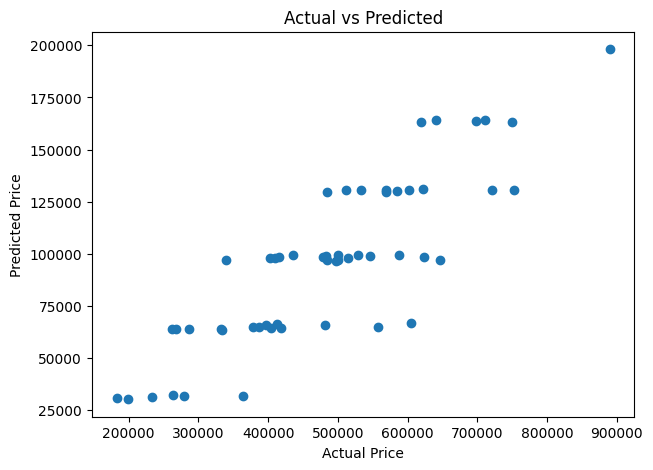

In [90]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [95]:
new_house = pd.DataFrame({
    "area_sqft": [150],
    "bedrooms": [3],
    "house_age_years": [5]
})

In [96]:
df.head()

,house_id,area_sqft,bedrooms,bathrooms,house_age_years,distance_city_km,has_garage,neighborhood_score,price_usd
0,H0001,1982.8,2,2.0,3,8.19,NaN,6.09,538319.98
1,H0002,2266.7,4,3.0,31,10.32,NaN,5.95,597950.89
2,H0003,1770.0,3,2.0,3,6.65,NaN,7.89,536099.35
3,H0004,2047.6,3,3.0,43,5.46,NaN,8.00,568164.49
4,H0005,1731.6,2,2.0,25,12.31,NaN,7.02,388126.72


In [101]:
new_house_scaled = scaler.transform(new_house)

prediction = model.predict(new_house_scaled)

print("Predicted Price:", prediction[0])

Predicted Price: 98836.67791235792


C:\Users\LEGION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
